# Name - Satyam Kale


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 710      |
|    ep_rew_mean     | 1.13e+04 |
| time/              |          |
|    fps             | 765      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 710         |
|    ep_rew_mean          | 1.06e+04    |
| time/                   |             |
|    fps                  | 568         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.004595096 |
|    clip_fraction        | 0.0195      |
|    clip_range           | 0.2         |
|    entropy_loss   

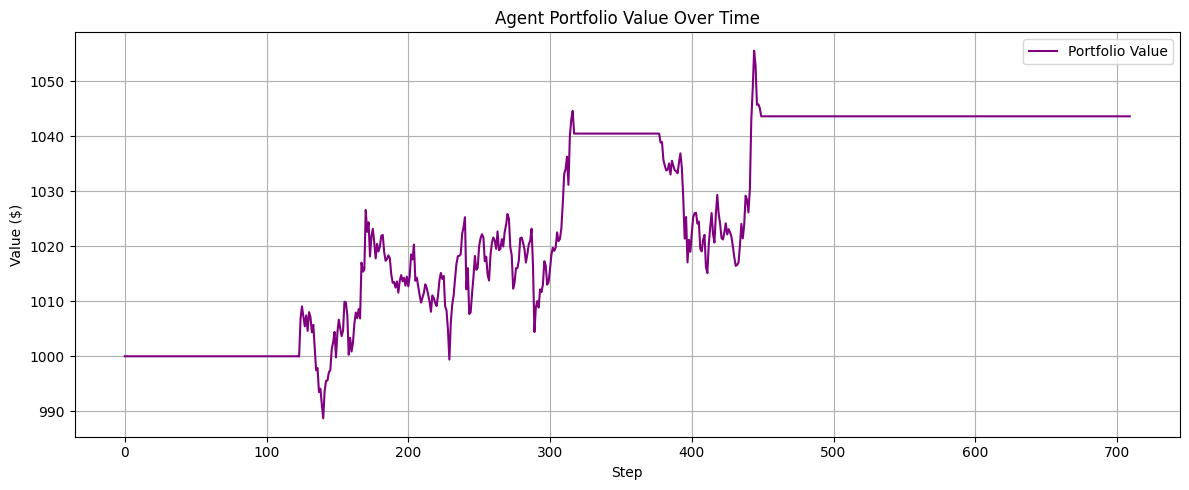

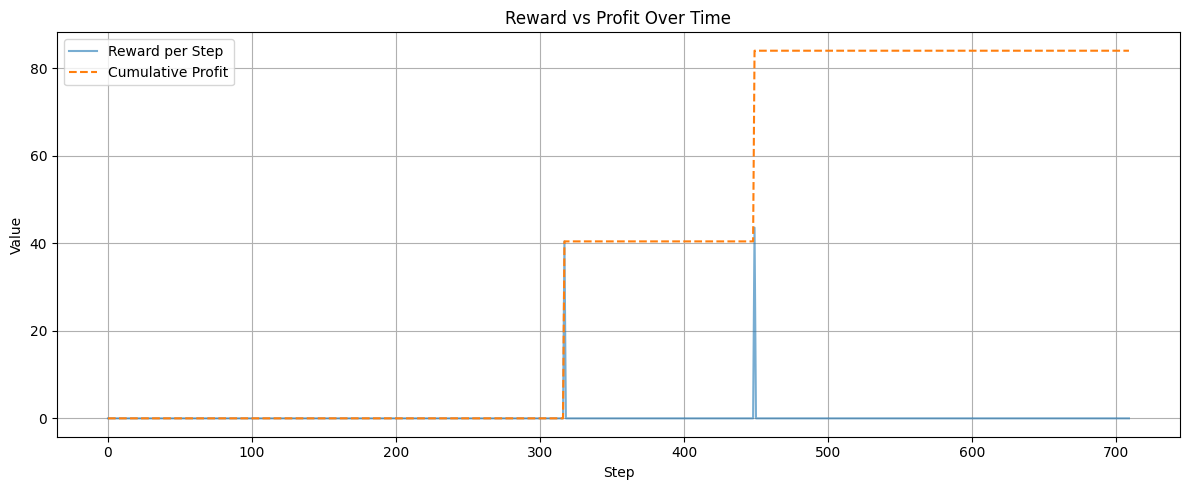

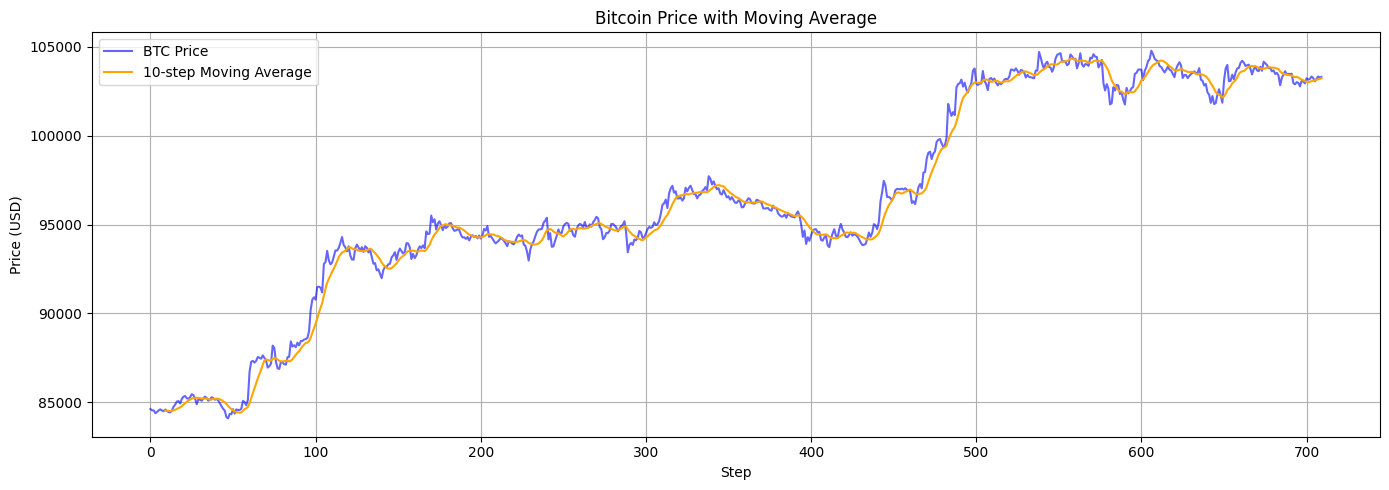

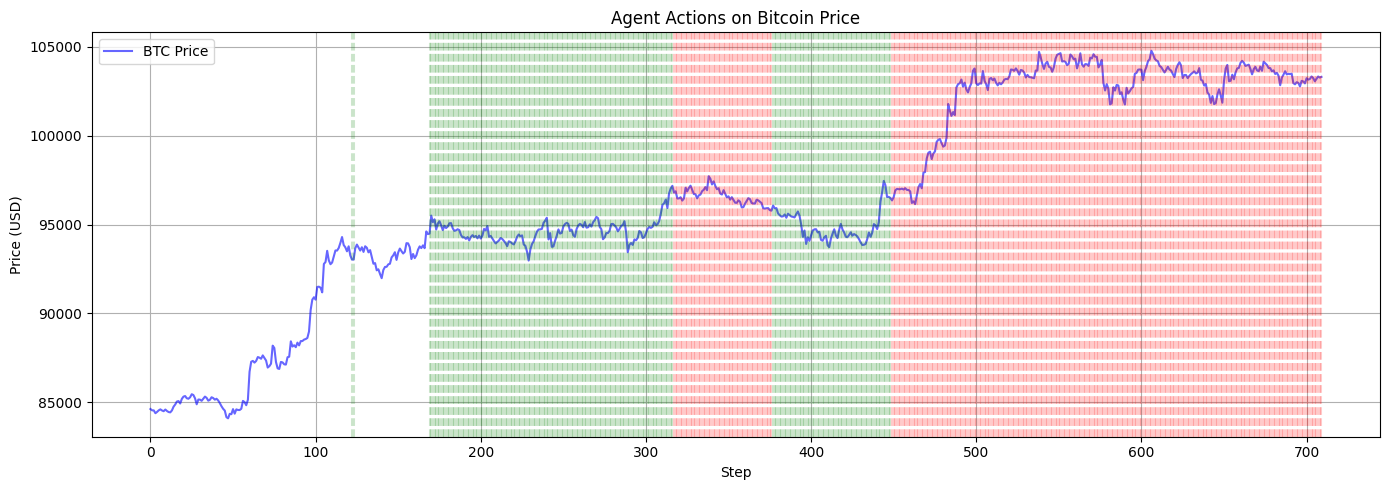


📈 Agent’s predicted next action: Sell
✅ Model saved as 'ppo_bitcoin_trading.zip'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from stable_baselines3 import PPO
from stablebaseline3_utils import (
    fetch_historical_prices,
    normalize_prices,
    BitcoinTradingEnv
)

# Load BTC price data
df = pd.read_csv("bitcoin_historical.csv", index_col="timestamp", parse_dates=True)
df = df.reset_index()
window_size = 10

# Create and train the environment
env = BitcoinTradingEnv(price_series=df, window_size=window_size)
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=10000)

# Evaluate model + log actions
test_env = BitcoinTradingEnv(price_series=df, window_size=window_size)
obs, _ = test_env.reset()
rewards, profits, actions, portfolio = [], [], [], []

while True:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = test_env.step(action)
    done = terminated or truncated

    rewards.append(reward)
    profits.append(test_env.total_profit)
    actions.append(int(action))  # ✅ Fix: cast to int
    net_worth = test_env.balance + test_env.shares_held * df["price"].iloc[test_env.current_step - 1]
    portfolio.append(net_worth)

    if done:
        break

print(f"✅ Final Profit: ${test_env.total_profit:.2f}")

# 📊 Action Counts
action_counts = Counter(actions)
print("\nAgent Action Counts:")
for act, count in action_counts.items():
    label = {0: "Hold", 1: "Buy", 2: "Sell"}[act]
    print(f"{label}: {count} actions")

# 📈 Portfolio Value Over Time
plt.figure(figsize=(12, 5))
plt.plot(portfolio, label="Portfolio Value", color='purple')
plt.title("Agent Portfolio Value Over Time")
plt.xlabel("Step")
plt.ylabel("Value ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 📉 Reward vs Profit
plt.figure(figsize=(12, 5))
plt.plot(rewards, label="Reward per Step", alpha=0.6)
plt.plot(profits, label="Cumulative Profit", linestyle='--')
plt.title("Reward vs Profit Over Time")
plt.xlabel("Step")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 📊 BTC Price with Moving Average
btc_plot = df["price"].values[window_size:]
rolling_mean = pd.Series(btc_plot).rolling(window=10).mean()

plt.figure(figsize=(14, 5))
plt.plot(btc_plot, label="BTC Price", color="blue", alpha=0.6)
plt.plot(rolling_mean, label="10-step Moving Average", color="orange")
plt.title("Bitcoin Price with Moving Average")
plt.xlabel("Step")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 📍 Agent Action Overlay on BTC Price
plt.figure(figsize=(14, 5))
plt.plot(btc_plot, label="BTC Price", color="blue", alpha=0.6)

for i, action in enumerate(actions):
    if action == 1:
        plt.axvline(x=i, color='green', linestyle='--', alpha=0.2, label='Buy' if i == 0 else "")
    elif action == 2:
        plt.axvline(x=i, color='red', linestyle='--', alpha=0.2, label='Sell' if i == 0 else "")

plt.title("Agent Actions on Bitcoin Price")
plt.xlabel("Step")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 📡 Predict Next BTC Trend Action (in live setting)
latest_window = df["norm_price"].values[-window_size:]
obs = latest_window.astype(np.float32).reshape(1, -1)
predicted_action, _ = model.predict(obs)

action_label = {0: "Hold", 1: "Buy", 2: "Sell"}[int(predicted_action[0])]
print(f"\n📈 Agent’s predicted next action: {action_label}")

# 💾 Save the model
model.save("ppo_bitcoin_trading")
print("✅ Model saved as 'ppo_bitcoin_trading.zip'")


In [2]:
df = fetch_historical_prices(days=60)
df = normalize_prices(df)

train_df = df.iloc[:24*30]
test_df = df.iloc[24*30:]

train_env = BitcoinTradingEnv(price_series=train_df, window_size=10)
test_env = BitcoinTradingEnv(price_series=test_df, window_size=10)

In [3]:
model = PPO("MlpPolicy", train_env, verbose=1)
model.learn(total_timesteps=10000)

# For evaluation
obs, _ = test_env.reset()
# ...
# Use test_env in evaluation loop instead of env


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 710      |
|    ep_rew_mean     | 4.55e+03 |
| time/              |          |
|    fps             | 702      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 710          |
|    ep_rew_mean          | -298         |
| time/                   |              |
|    fps                  | 534          |
|    iterations           | 2            |
|    time_elapsed         | 7            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0060302457 |
|    clip_fraction        | 0.0558       |
|    clip_range           | 0.2          |
|    en